# Preprocessing — Member 4 (Second Turn): Class Imbalance Experiment & PageValues Decision

## Online Shopper Purchase Likelihood Prediction System

**IT3051 – Fundamentals of Data Mining | Mini Project 2026 | Group DS_WE_01.02**

This notebook completes the preprocessing-stage experiments after feature selection.

It builds on:

- **Member 4 (first turn):** data validation, duplicate removal, and stratified train/test split
- **Member 1:** feature engineering and transformations
- **Member 2:** encoding and scaling implementation in `src/preprocessing/encoding_scaling.py`
- **Member 3:** feature selection, resulting in `X_train_selected.csv`

Two preprocessing questions are investigated using cross-validation on the **training set only**:

1. How do different class-imbalance strategies affect model performance?
2. What is the effect of including or excluding `PageValues`?

The following imbalance strategies are compared:

- Baseline — no imbalance handling
- Class weighting
- SMOTE

Two representative models are used:

- Logistic Regression
- Random Forest

The test set is **not loaded or used** in this notebook. It remains untouched for the final model evaluation stage.

### Important methodological point

The selected training data is used before encoding and scaling. Encoding and scaling are fitted **inside each cross-validation fold** through the preprocessing pipeline. This prevents information from the validation fold from influencing the preprocessing steps.

The experiments in this notebook are used to make preprocessing decisions. They do **not** represent final model selection.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sys.path.insert(0, os.path.abspath(".."))

from src.preprocessing.encoding_scaling import (
    CATEGORICAL_COLUMNS,
    build_preprocessor,
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Load the selected training data

Only the training data is loaded.

Feature selection has already been completed by Member 3, so this notebook starts from:

`data/processed/X_train_selected.csv`

The target is loaded separately from:

`data/y_train.csv`

The test set is deliberately not loaded because it must remain untouched until final evaluation.

Encoding and scaling are performed inside each cross-validation fold rather than before cross-validation.

In [2]:
X_train = pd.read_csv("../data/processed/X_train_selected.csv")

y_train = (
    pd.read_csv("../data/y_train.csv")
    .squeeze("columns")
    .astype(int)
)

assert len(X_train) == len(y_train)

print("Training rows:", len(X_train))
print("Training features:", X_train.shape[1])
print("Purchase rate in training data: {:.3f}".format(y_train.mean()))

Training rows: 9764
Training features: 18
Purchase rate in training data: 0.156


## Check the selected features

Member 3's feature selection stage retained the selected predictor variables.

Before continuing, the feature names and target distribution are checked to make sure the training data has been loaded correctly.

In [3]:
print("Selected features:")
for column in X_train.columns:
    print("-", column)

print("\nTarget distribution:")
print(y_train.value_counts())

print("\nTarget percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Selected features:
- Administrative
- Administrative_Duration
- Informational
- Informational_Duration
- BounceRates
- ExitRates
- PageValues
- SpecialDay
- Month
- OperatingSystems
- Browser
- TrafficType
- VisitorType
- Weekend
- TotalPages
- TotalDuration
- AvgTimePerPage
- VisitorType_Weekend

Target distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Target percentages:
Revenue
0    84.37
1    15.63
Name: proportion, dtype: float64


In [4]:
selected_categorical_columns = [
    column
    for column in CATEGORICAL_COLUMNS
    if column in X_train.columns
]

selected_numeric_columns = [
    column
    for column in X_train.columns
    if column not in selected_categorical_columns
]

print("Categorical features:", len(selected_categorical_columns))
print("Numerical features:", len(selected_numeric_columns))

print("\nCategorical columns:")
print(selected_categorical_columns)

print("\nNumerical columns:")
print(selected_numeric_columns)

Categorical features: 7
Numerical features: 11

Categorical columns:
['Month', 'OperatingSystems', 'Browser', 'TrafficType', 'VisitorType', 'Weekend', 'VisitorType_Weekend']

Numerical columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'TotalPages', 'TotalDuration', 'AvgTimePerPage']


## Experiment Setup

### Cross-validation

A 5-fold stratified cross-validation strategy is used.

Stratification ensures that each validation fold maintains approximately the same purchase/non-purchase distribution as the complete training set.

### Models

Two representative models are evaluated:

- Logistic Regression
- Random Forest

These models are used to investigate preprocessing choices. They are **not treated as the final model selection**.

### Metrics

The following metrics are used:

- F1-score
- Precision
- Recall
- ROC-AUC
- PR-AUC

Accuracy is not emphasized because the dataset is imbalanced and a model could obtain high accuracy simply by predicting the majority class.

### Leakage prevention

For every cross-validation fold:

1. The preprocessing pipeline is fitted only on the fold's training portion.
2. Encoding and scaling are performed within the pipeline.
3. SMOTE, when used, is applied only to the fold's training portion.
4. The validation portion is never used during preprocessing or resampling.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

## Helper Functions

The following functions create the preprocessing and modelling pipeline.

The preprocessing stage is created separately for each cross-validation fold.

For the class-weighting experiment:

- `class_weight="balanced"` is used.

For the baseline:

- no class weighting is applied.

For SMOTE:

- the training data is resampled inside the `imblearn` pipeline.

In [6]:
def make_model(model_name, weighted=False):
    class_weight = "balanced" if weighted else None

    if model_name == "Logistic Regression":
        return LogisticRegression(
            max_iter=2000,
            class_weight=class_weight,
            random_state=RANDOM_STATE
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=200,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    raise ValueError(f"Unknown model: {model_name}")

In [7]:
def make_pipeline(method, model_name, numeric_cols):
    preprocessor = build_preprocessor(
        numeric_cols,
        selected_categorical_columns
    )

    steps = [
        ("prep", preprocessor)
    ]

    if method == "SMOTE":
        steps.append(
            ("smote", SMOTE(random_state=RANDOM_STATE))
        )

    steps.append(
        (
            "model",
            make_model(
                model_name,
                weighted=(method == "Class weighting")
            )
        )
    )

    return ImbPipeline(steps)

In [8]:
def evaluate(method, model_name, X, numeric_cols):
    pipeline = make_pipeline(
        method,
        model_name,
        numeric_cols
    )

    scores = cross_validate(
        pipeline,
        X,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )

    row = {}

    for metric in SCORING:
        values = scores["test_" + metric]

        row[metric] = values.mean()
        row[metric + "_std"] = values.std()

    return row

# Experiment 1 — Class Imbalance Strategy

The following three strategies are compared:

1. **Baseline** — no imbalance handling
2. **Class weighting** — `class_weight="balanced"`
3. **SMOTE** — synthetic minority oversampling applied within each training fold

Both Logistic Regression and Random Forest are evaluated.

The goal is not to select a final model here. Instead, the experiment identifies how different imbalance strategies affect predictive performance and the precision–recall trade-off.

In [9]:
rows = []

for model_name in [
    "Logistic Regression",
    "Random Forest"
]:
    for method in [
        "Baseline",
        "Class weighting",
        "SMOTE"
    ]:
        print(
            f"Running: {model_name} + {method}"
        )

        result = evaluate(
            method,
            model_name,
            X_train,
            selected_numeric_columns
        )

        rows.append(
            {
                "model": model_name,
                "method": method,
                **result
            }
        )

imbalance_results = pd.DataFrame(rows)

imbalance_results[
    [
        "model",
        "method",
        "f1",
        "precision",
        "recall",
        "roc_auc",
        "pr_auc"
    ]
].round(4)

Running: Logistic Regression + Baseline
Running: Logistic Regression + Class weighting
Running: Logistic Regression + SMOTE
Running: Random Forest + Baseline
Running: Random Forest + Class weighting
Running: Random Forest + SMOTE


,model,method,f1,precision,recall,roc_auc,pr_auc
0,Logistic Regression,Baseline,0.6159,0.7057,0.5472,0.9124,0.6865
1,Logistic Regression,Class weighting,0.6477,0.5443,0.8008,0.9167,0.6663
2,Logistic Regression,SMOTE,0.6428,0.5343,0.8080,0.9141,0.6649
3,Random Forest,Baseline,0.6218,0.7724,0.5210,0.9236,0.7443
4,Random Forest,Class weighting,0.6131,0.7753,0.5079,0.9245,0.7396
5,Random Forest,SMOTE,0.6750,0.6586,0.6933,0.9250,0.7005


In [10]:
imbalance_results[
    [
        "model",
        "method",
        "f1",
        "f1_std",
        "precision",
        "precision_std",
        "recall",
        "recall_std",
        "roc_auc",
        "roc_auc_std",
        "pr_auc",
        "pr_auc_std",
    ]
].round(4)

,model,method,f1,f1_std,precision,precision_std,recall,recall_std,roc_auc,roc_auc_std,pr_auc,pr_auc_std
0,Logistic Regression,Baseline,0.6159,0.0140,0.7057,0.0240,0.5472,0.0223,0.9124,0.0074,0.6865,0.0190
1,Logistic Regression,Class weighting,0.6477,0.0136,0.5443,0.0179,0.8008,0.0212,0.9167,0.0078,0.6663,0.0210
2,Logistic Regression,SMOTE,0.6428,0.0146,0.5343,0.0208,0.8080,0.0225,0.9141,0.0075,0.6649,0.0232
3,Random Forest,Baseline,0.6218,0.0207,0.7724,0.0225,0.5210,0.0261,0.9236,0.0038,0.7443,0.0170
4,Random Forest,Class weighting,0.6131,0.0258,0.7753,0.0212,0.5079,0.0327,0.9245,0.0029,0.7396,0.0166
5,Random Forest,SMOTE,0.6750,0.0168,0.6586,0.0190,0.6933,0.0309,0.9250,0.0036,0.7005,0.0244


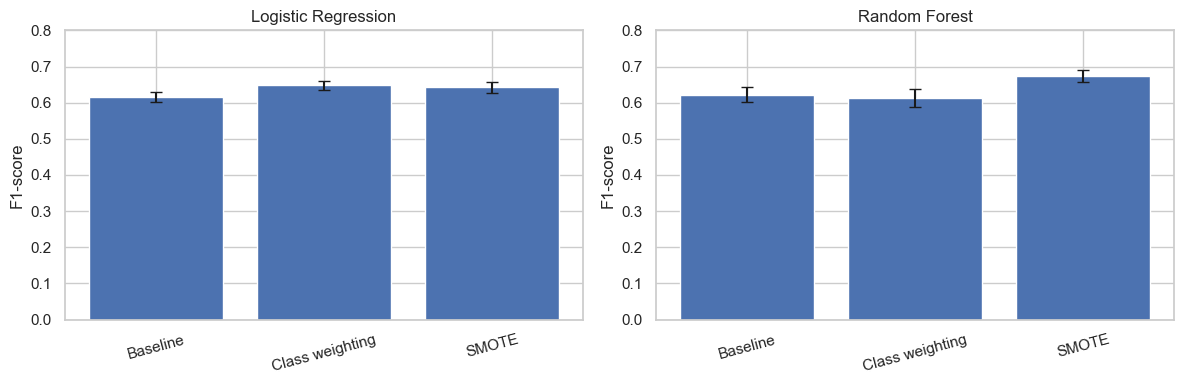

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

for ax, model_name in zip(
    axes,
    ["Logistic Regression", "Random Forest"]
):
    subset = imbalance_results[
        imbalance_results["model"] == model_name
    ]

    ax.bar(
        subset["method"],
        subset["f1"],
        yerr=subset["f1_std"],
        capsize=4
    )

    ax.set_title(model_name)
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 0.8)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Interpretation — Class Imbalance

The results should be interpreted using both the mean performance and the fold-to-fold variation.

For Logistic Regression, class weighting and SMOTE can improve the balance between precision and recall compared with the baseline. However, if their F1 differences are small relative to the cross-validation variation, the results should not be interpreted as evidence that one method is definitively superior.

For Random Forest, the effect of imbalance handling may differ from Logistic Regression. In particular, SMOTE may improve the F1-score in this experiment, while class weighting may not provide the same improvement.

The experiments also show that imbalance handling can substantially change recall and precision. Therefore, the choice should not be based on F1-score alone.

ROC-AUC and PR-AUC are also considered because they provide information about ranking performance. If these metrics change only slightly while F1, precision, and recall change substantially, the imbalance method may primarily be changing the decision behaviour rather than substantially improving ranking ability.

### Important limitation of SMOTE

SMOTE is applied after the categorical variables have been encoded by the preprocessing pipeline. Consequently, synthetic samples can contain fractional values in one-hot encoded columns.

For example, a synthetic observation could contain a value such as `0.4` in a one-hot feature.

Therefore, the SMOTE results should be interpreted cautiously. A categorical-aware alternative such as SMOTENC could be investigated if required.

## Decision — Class Imbalance

No single imbalance strategy is permanently selected at this preprocessing stage.

Baseline, class weighting, and SMOTE will remain candidate configurations for the later model evaluation stage.

The final configuration should be selected based on:

- model performance,
- precision and recall trade-offs,
- PR-AUC and ROC-AUC,
- cross-validation variation,
- and the practical requirements of the purchase-likelihood system.

Threshold tuning may also be considered because the default 0.5 threshold does not necessarily provide the desired precision–recall balance for an imbalanced target.

# Experiment 2 — PageValues: With and Without

`PageValues` was identified during exploratory analysis as a highly predictive feature.

Because of its strong relationship with the target, two issues need to be considered:

1. How much predictive performance is lost when `PageValues` is removed?
2. Is `PageValues` legitimately available at the intended prediction point?

To isolate the effect of the feature, the same imbalance strategy — class weighting — is used for both feature sets.

The comparison is therefore:

- With `PageValues`
- Without `PageValues`

The test set remains untouched.

In [12]:
assert "PageValues" in X_train.columns

numeric_no_pv = [
    column
    for column in selected_numeric_columns
    if column != "PageValues"
]

X_no_pv = X_train.drop(
    columns=["PageValues"]
)

print("Features with PageValues:", X_train.shape[1])
print("Features without PageValues:", X_no_pv.shape[1])

Features with PageValues: 18
Features without PageValues: 17


In [13]:
rows = []

for model_name in [
    "Logistic Regression",
    "Random Forest"
]:
    print(f"\nEvaluating {model_name} with PageValues...")

    with_pv = evaluate(
        "Class weighting",
        model_name,
        X_train,
        selected_numeric_columns
    )

    print(f"Evaluating {model_name} without PageValues...")

    without_pv = evaluate(
        "Class weighting",
        model_name,
        X_no_pv,
        numeric_no_pv
    )

    rows.append(
        {
            "model": model_name,
            "features": "With PageValues",
            **with_pv
        }
    )

    rows.append(
        {
            "model": model_name,
            "features": "Without PageValues",
            **without_pv
        }
    )

pagevalues_results = pd.DataFrame(rows)

pagevalues_results[
    [
        "model",
        "features",
        "f1",
        "precision",
        "recall",
        "roc_auc",
        "pr_auc"
    ]
].round(4)


Evaluating Logistic Regression with PageValues...
Evaluating Logistic Regression without PageValues...

Evaluating Random Forest with PageValues...
Evaluating Random Forest without PageValues...


,model,features,f1,precision,recall,roc_auc,pr_auc
0,Logistic Regression,With PageValues,0.6477,0.5443,0.8008,0.9167,0.6663
1,Logistic Regression,Without PageValues,0.3974,0.2712,0.7431,0.7515,0.3335
2,Random Forest,With PageValues,0.6131,0.7753,0.5079,0.9245,0.7396
3,Random Forest,Without PageValues,0.1324,0.5650,0.0754,0.7728,0.3679


In [14]:
pagevalues_results[
    [
        "model",
        "features",
        "f1",
        "f1_std",
        "precision",
        "precision_std",
        "recall",
        "recall_std",
        "roc_auc",
        "roc_auc_std",
        "pr_auc",
        "pr_auc_std",
    ]
].round(4)

,model,features,f1,f1_std,precision,precision_std,recall,recall_std,roc_auc,roc_auc_std,pr_auc,pr_auc_std
0,Logistic Regression,With PageValues,0.6477,0.0136,0.5443,0.0179,0.8008,0.0212,0.9167,0.0078,0.6663,0.0210
1,Logistic Regression,Without PageValues,0.3974,0.0126,0.2712,0.0099,0.7431,0.0177,0.7515,0.0220,0.3335,0.0336
2,Random Forest,With PageValues,0.6131,0.0258,0.7753,0.0212,0.5079,0.0327,0.9245,0.0029,0.7396,0.0166
3,Random Forest,Without PageValues,0.1324,0.0272,0.5650,0.0498,0.0754,0.0175,0.7728,0.0150,0.3679,0.0217


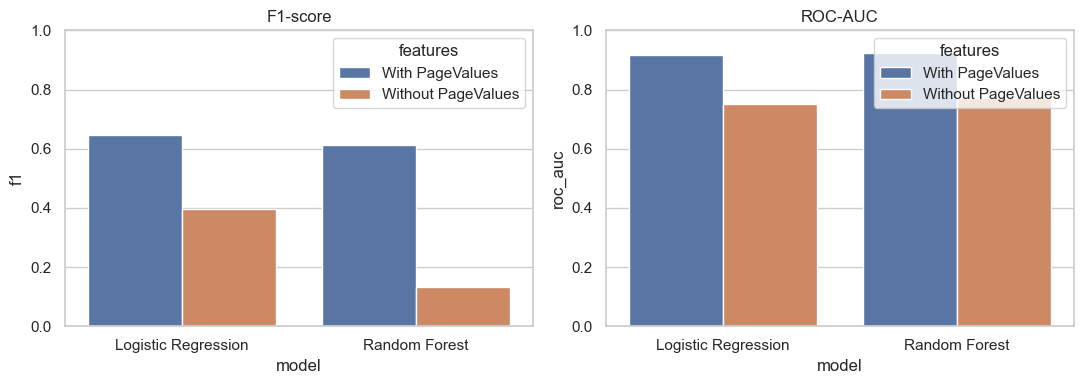

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

for ax, metric, title in zip(
    axes,
    ["f1", "roc_auc"],
    ["F1-score", "ROC-AUC"]
):
    sns.barplot(
        data=pagevalues_results,
        x="model",
        y=metric,
        hue="features",
        ax=ax
    )

    ax.set_title(title)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Interpretation — PageValues

The comparison shows how strongly model performance depends on `PageValues`.

If removing `PageValues` produces a substantial decrease in F1-score, ROC-AUC, and/or PR-AUC, this indicates that `PageValues` contains strong predictive information for the target in this dataset.

However, strong predictive performance alone does not establish that `PageValues` is suitable for deployment.

The feature must also satisfy two conditions:

1. It must be available at the intended prediction time.
2. Its calculation must not use information that would only become available after the prediction point.

The intended prediction point for this project is during an active session, before checkout is completed.

Therefore, the availability and calculation of `PageValues` must be verified using the dataset documentation and the original study before making a final deployment decision.

The results of this experiment therefore describe the predictive effect of the feature, but they do not by themselves prove that the feature is leakage-free or deployable.

## Decision — PageValues

`PageValues` will not be automatically removed solely because it is highly predictive.

Instead, the project will report both:

- models using `PageValues`
- models without `PageValues`

The final use of the feature will depend on verification of:

- how `PageValues` is calculated,
- whether it contains information related to the outcome that would not be available at prediction time,
- and whether the value can be obtained during an active session before checkout.

If `PageValues` is confirmed to be available before prediction and does not introduce target leakage, it can remain a candidate feature.

If it is not available at the intended prediction point or is found to contain post-outcome information, models without `PageValues` should be used for the deployable scenario.

# Summary of Preprocessing Decisions

| Question | Finding | Decision for Stage 6 |
|---|---|---|
| Class imbalance | The effect differs between algorithms and strategies | Compare baseline, class weighting, and SMOTE |
| Class weighting | Can improve recall and F1 for some models | Keep as a candidate configuration |
| SMOTE | Can improve F1 for some models, but is applied after one-hot encoding | Keep as a candidate and interpret cautiously |
| `PageValues` | Removing it can substantially reduce predictive performance | Evaluate models both with and without it |
| `PageValues` safety | Predictive strength alone does not establish deployability | Verify availability and leakage before final selection |
| Test set | Not used in these experiments | Preserve for final evaluation |

### Final preprocessing pipeline

Validation and duplicate removal  
↓  
Stratified train/test split  
↓  
Feature engineering  
↓  
Feature selection  
↓  
**Class imbalance and PageValues experiments**  
↓  
Final model comparison and evaluation